In [97]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier 
import statsmodels.api as sm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import seaborn as sns
import matplotlib.pyplot as plt


url = 'https://raw.githubusercontent.com/AntonioNazar/Oracle_Desafio_2/refs/heads/main/telecom_churn.csv'

# 1. Importando dataset

In [98]:
df = pd.read_csv(url)
df.head()

,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,charges_monthly,charges_total,feature_citizen
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,0
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   churn              7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   object 
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [100]:
px.histogram(df, x='churn', color='churn', title='Distribuição de Churn')

# 2. Pré-processamento

### 2.1 One-hot-encode

In [101]:
def one_hot_encode(df, lista_colunas):
    one_hot = make_column_transformer((OneHotEncoder(drop = 'if_binary'), lista_colunas), remainder='passthrough', sparse_threshold=0)
    one_hot.fit(df[lista_colunas])
    nomes_colunas = one_hot.get_feature_names_out(lista_colunas)
    df_encode = pd.DataFrame(one_hot.transform(df[lista_colunas]), columns=nomes_colunas)
    return df_encode

In [102]:
lista_colunas_categoricas = ['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service',
'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

df_encode = one_hot_encode(df, lista_colunas_categoricas)

df_encode.head()

,onehotencoder__churn_Yes,onehotencoder__gender_Male,onehotencoder__senior_citizen_Yes,onehotencoder__partner_Yes,onehotencoder__dependents_Yes,onehotencoder__phone_service_Yes,onehotencoder__multiple_lines_No,onehotencoder__multiple_lines_No phone service,onehotencoder__multiple_lines_Yes,onehotencoder__internet_service_DSL,...,onehotencoder__streaming_movies_No internet service,onehotencoder__streaming_movies_Yes,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__paperless_billing_Yes,onehotencoder__payment_method_Bank transfer (automatic),onehotencoder__payment_method_Credit card (automatic),onehotencoder__payment_method_Electronic check,onehotencoder__payment_method_Mailed check
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### 2.2 Normalização

In [103]:
def normalizar(df, lista_colunas):
    scaler = MinMaxScaler()
    df_norm = scaler.fit_transform(df[lista_colunas])
    df_norm = pd.DataFrame(df_norm, columns=lista_colunas)
    return df_norm

In [104]:
lista_colunas_numericas = ['tenure', 'charges_monthly', 'charges_total']

df_norm = normalizar(df, lista_colunas_numericas)

df_norm.head()

,tenure,charges_monthly,charges_total
0,0.125000,0.471144,0.068315
1,0.125000,0.414428,0.062454
2,0.055556,0.553731,0.032338
3,0.180556,0.793532,0.142531
4,0.041667,0.653234,0.030789


In [105]:
df_final = pd.concat([df_norm, df_encode], axis=1).astype(float)

In [106]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   tenure                                                   7043 non-null   float64
 1   charges_monthly                                          7043 non-null   float64
 2   charges_total                                            7043 non-null   float64
 3   onehotencoder__churn_Yes                                 7043 non-null   float64
 4   onehotencoder__gender_Male                               7043 non-null   float64
 5   onehotencoder__senior_citizen_Yes                        7043 non-null   float64
 6   onehotencoder__partner_Yes                               7043 non-null   float64
 7   onehotencoder__dependents_Yes                            7043 non-null   float64
 8   onehotencoder__phone_service

### 2.3 Balanceamento dos dados (undersampling)

In [107]:
df_final = pd.concat([df_final.query('onehotencoder__churn_Yes == 1').iloc[:1869,:],df_final.query('onehotencoder__churn_Yes == 0').iloc[:1869,:]], ignore_index=True)


In [108]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3738 entries, 0 to 3737
Data columns (total 41 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   tenure                                                   3738 non-null   float64
 1   charges_monthly                                          3738 non-null   float64
 2   charges_total                                            3738 non-null   float64
 3   onehotencoder__churn_Yes                                 3738 non-null   float64
 4   onehotencoder__gender_Male                               3738 non-null   float64
 5   onehotencoder__senior_citizen_Yes                        3738 non-null   float64
 6   onehotencoder__partner_Yes                               3738 non-null   float64
 7   onehotencoder__dependents_Yes                            3738 non-null   float64
 8   onehotencoder__phone_service

In [109]:
df_final.head()

,tenure,charges_monthly,charges_total,onehotencoder__churn_Yes,onehotencoder__gender_Male,onehotencoder__senior_citizen_Yes,onehotencoder__partner_Yes,onehotencoder__dependents_Yes,onehotencoder__phone_service_Yes,onehotencoder__multiple_lines_No,...,onehotencoder__streaming_movies_No internet service,onehotencoder__streaming_movies_Yes,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__paperless_billing_Yes,onehotencoder__payment_method_Bank transfer (automatic),onehotencoder__payment_method_Credit card (automatic),onehotencoder__payment_method_Electronic check,onehotencoder__payment_method_Mailed check
0,0.055556,0.553731,0.032338,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.180556,0.793532,0.142531,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.041667,0.653234,0.030789,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.625000,0.442289,0.321424,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.013889,0.068159,0.002890,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [110]:
px.histogram(df_final, x='onehotencoder__churn_Yes',color='onehotencoder__churn_Yes', title='Distribuição de Churn')

# 3. Analisando correlação entre as features

Para analisar a seguinte matriz a seguir, será seguida a seguinte metodologia:
1. Visualizar as features com significativa correlação(valor absoluto maior que 0.3) com a variável objetivo (churn)
2. Caso ela seja primeira, escolher ela, caso não, visualizar sua correlação com as outras

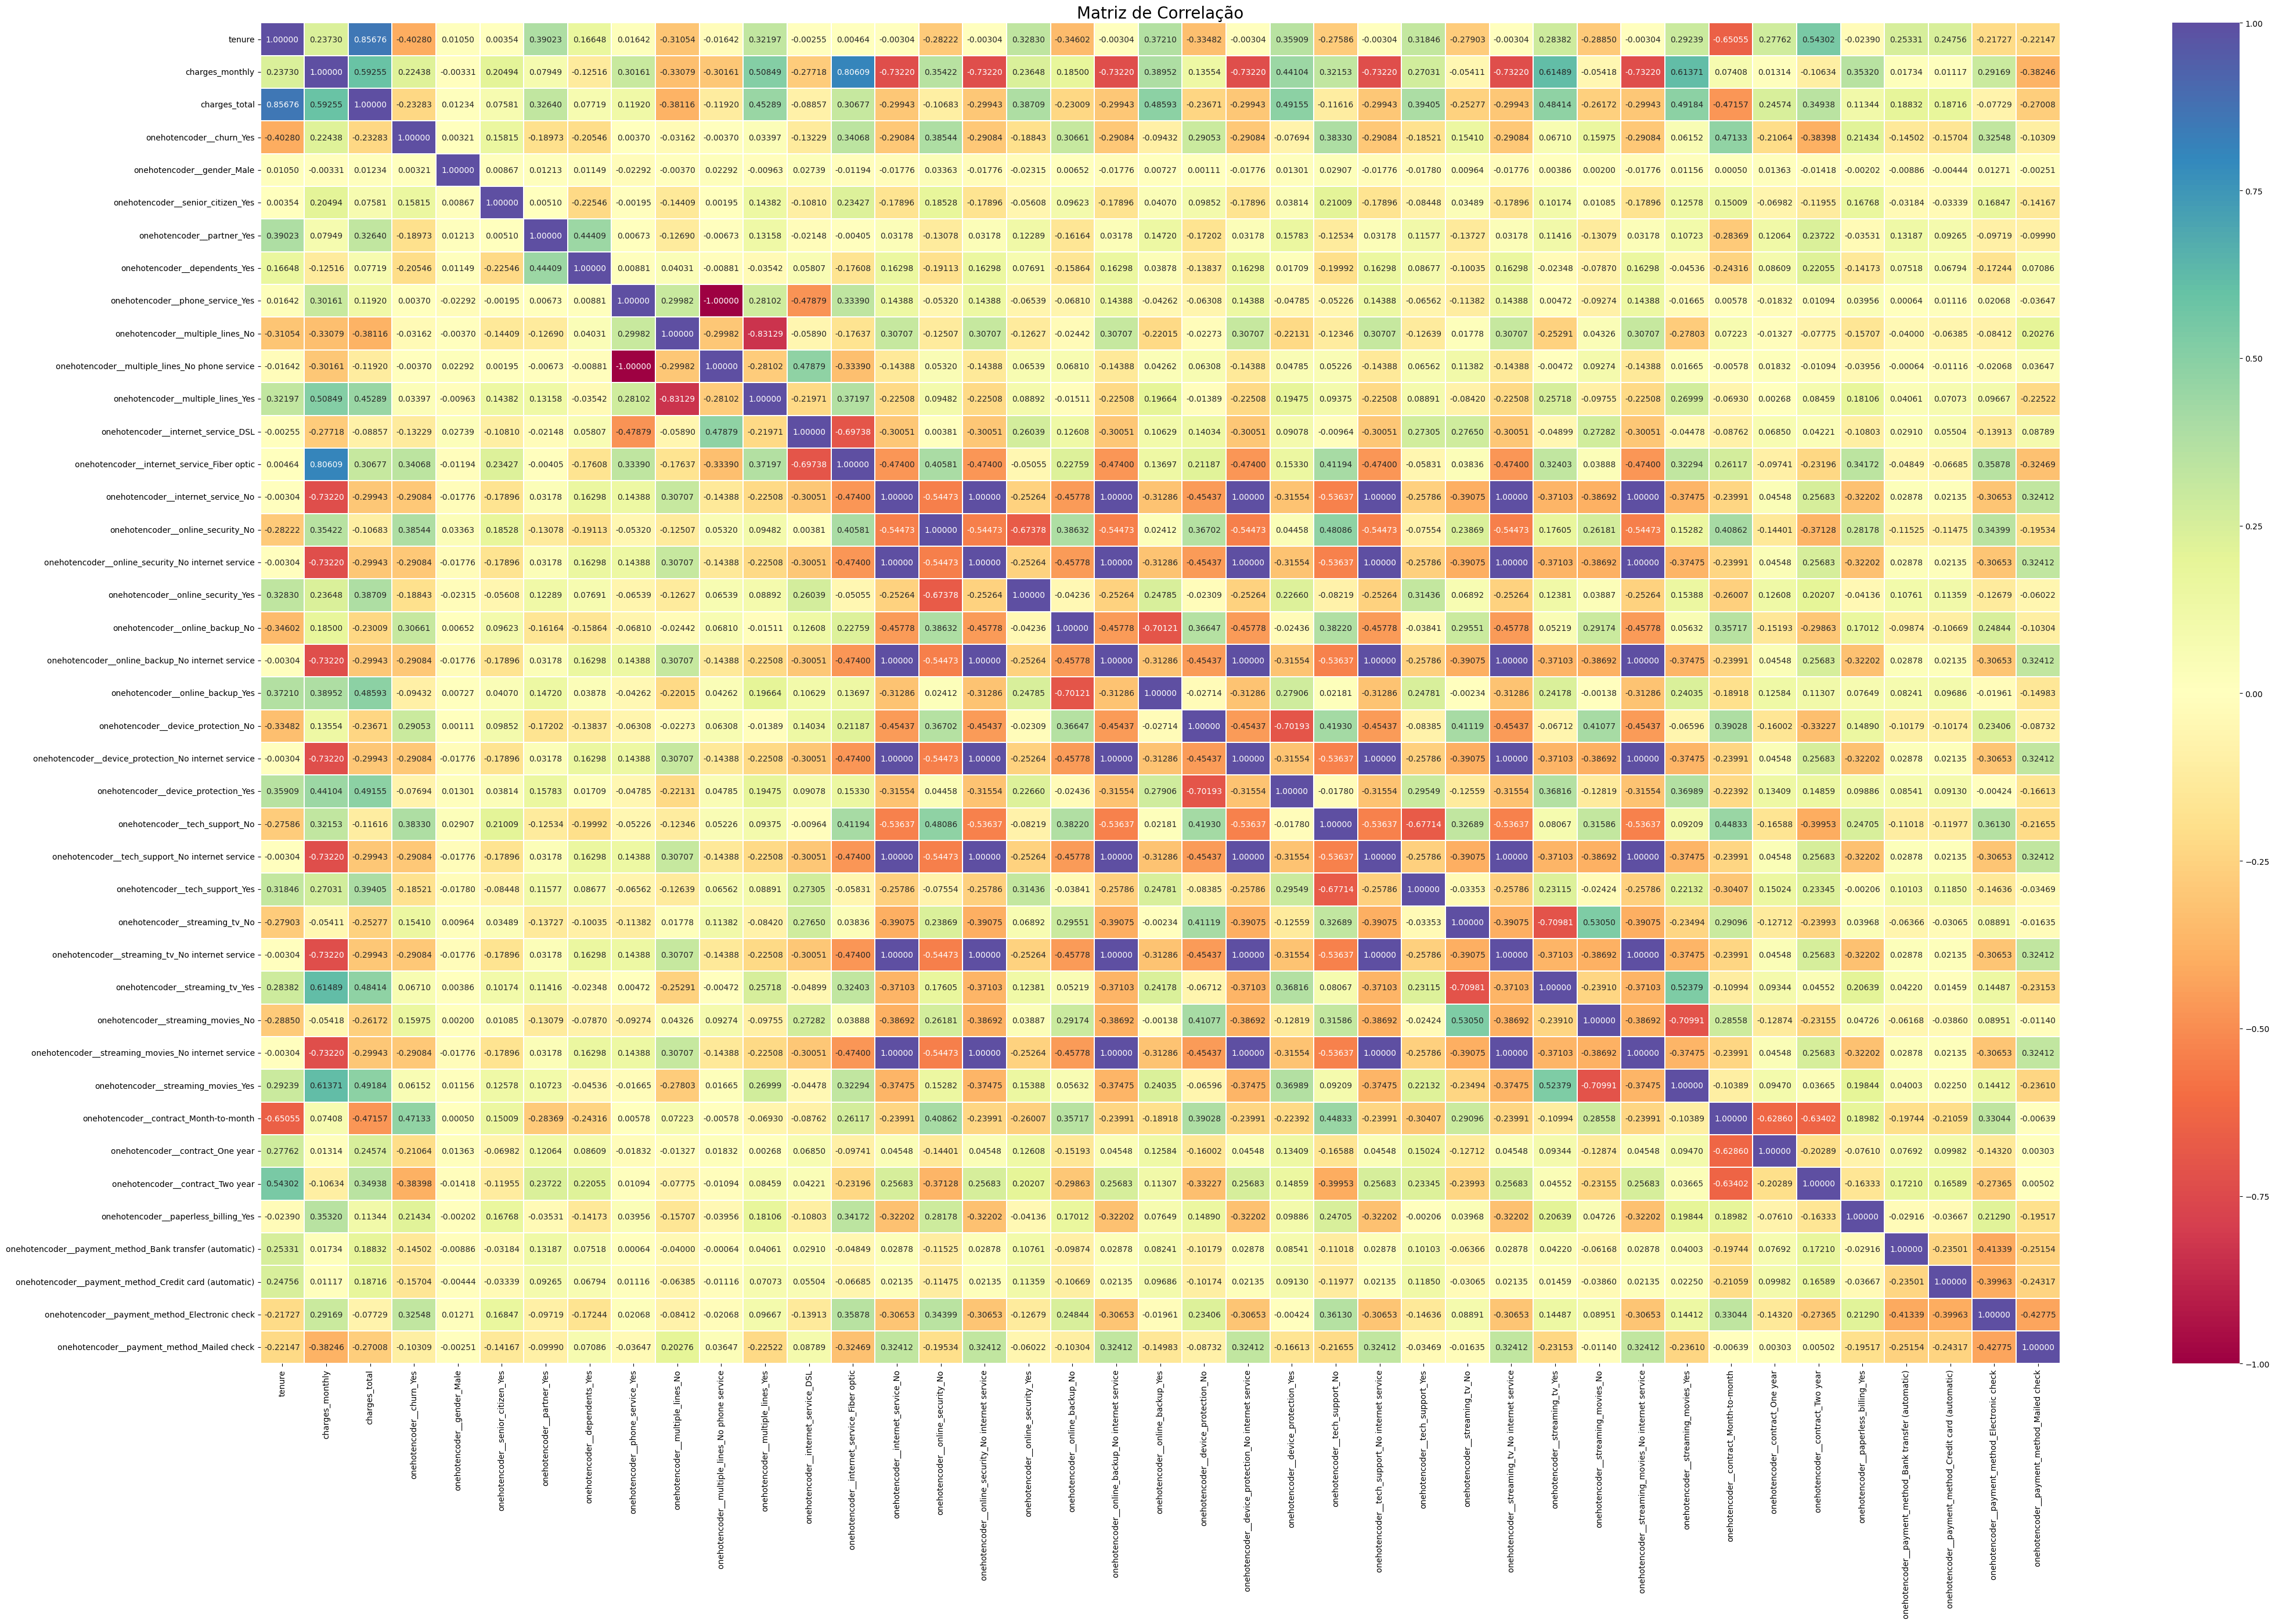

In [111]:
corr = df_final.corr()


plt.figure(figsize=(50,30))

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt=".5f",
    linewidths=0.3,
)

plt.title("Matriz de Correlação", fontsize=20)
plt.show()

Foi perceptível que as features foram significativas: 
1. onehotencoder__internet_service_Fiber optic	
2. onehotencoder__online_security_No
3. onehotencoder__tech_support_No
4. onehotencoder__contract_Month-to-month	
5. onehotencoder__contract_Two year
6. onehotencoder__payment_method_Electronic check
7. tenure

Mas é necessário perceber que o contrato mensal e de dois anos tem uma forte correlação, sendo descartada a com menor correlação com a variável alvo, ou seja, a onehotencoder__contract_Two year.

# 4. Treinando modelos

In [112]:
colunas_significativas = [ 'onehotencoder__contract_Month-to-month',
       'tenure', 'onehotencoder__online_security_No',
       'onehotencoder__tech_support_No',
       'onehotencoder__internet_service_Fiber optic',
       'onehotencoder__payment_method_Electronic check']
colunas_significativas

['onehotencoder__contract_Month-to-month',
 'tenure',
 'onehotencoder__online_security_No',
 'onehotencoder__tech_support_No',
 'onehotencoder__internet_service_Fiber optic',
 'onehotencoder__payment_method_Electronic check']

separação do dataset em treino e teste

In [113]:
sm.add_constant(df_final)

,const,tenure,charges_monthly,charges_total,onehotencoder__churn_Yes,onehotencoder__gender_Male,onehotencoder__senior_citizen_Yes,onehotencoder__partner_Yes,onehotencoder__dependents_Yes,onehotencoder__phone_service_Yes,...,onehotencoder__streaming_movies_No internet service,onehotencoder__streaming_movies_Yes,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__paperless_billing_Yes,onehotencoder__payment_method_Bank transfer (automatic),onehotencoder__payment_method_Credit card (automatic),onehotencoder__payment_method_Electronic check,onehotencoder__payment_method_Mailed check
0,1.0,0.055556,0.553731,0.032338,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.180556,0.793532,0.142531,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.041667,0.653234,0.030789,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.625000,0.442289,0.321424,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.013889,0.068159,0.002890,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,1.0,0.944444,0.679104,0.677362,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
3734,1.0,0.805556,0.414428,0.403590,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3735,1.0,0.263889,0.421393,0.149433,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3736,1.0,0.180556,0.264179,0.064388,0.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [114]:
x_treino, x_teste, y_treino, y_teste = train_test_split(df_final[colunas_significativas], df_final['onehotencoder__churn_Yes'], test_size=0.2, random_state=404)

In [ ]:
def calc_metricas(modelo, x_treino, y_treino, is_statsmodels):
    y_pred = modelo.predict(x_treino)

    # O modelo Logit do statsmodels retorna uma matriz coluna de probabilidades, então precisamos convertê-la em respostas binárias
    if(is_statsmodels==True):
        y_pred = (y_pred >= 0.5).astype(int)

    accuracy = accuracy_score(y_treino, y_pred)
    precision = precision_score(y_treino, y_pred, zero_division=0)
    recall = recall_score(y_treino, y_pred, zero_division=0)
    f1 = f1_score(y_treino, y_pred, zero_division=0)
    conf_matrix = confusion_matrix(y_treino, y_pred)
    return accuracy, precision, recall, f1, conf_matrix

def print_metricas(metricas):
    accuracy, precision, recall, f1, conf_matrix = metricas
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Matriz de Confusão:")

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Spectral')

### 4.1 Modelo ingênuo

Serve de base para avaliação dos outros modelos

In [116]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)
dummy.score(x_teste, y_teste)

0.4799465240641711

Acurácia: 0.5050
Precisão: 0.0000
Recall: 0.0000
F1-Score: 0.0000
Matriz de Confusão:


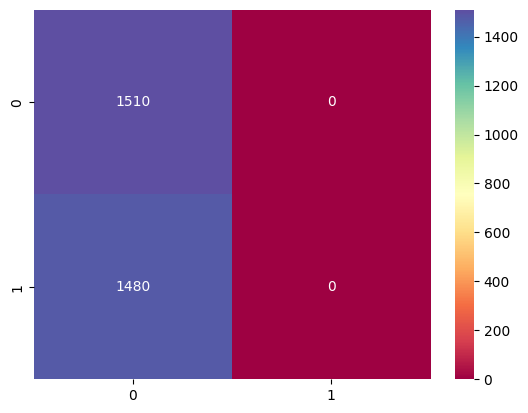

In [117]:
metricas = calc_metricas(dummy, x_treino, y_treino, False)
print_metricas(metricas)

### 4.2 Regressão Logística

In [118]:
reg_log = sm.Logit(y_treino, x_treino, hasconst = True).fit()

Optimization terminated successfully.
         Current function value: 0.504660
         Iterations 6


In [119]:
print(reg_log.summary())

                              Logit Regression Results                              
Dep. Variable:     onehotencoder__churn_Yes   No. Observations:                 2990
Model:                                Logit   Df Residuals:                     2984
Method:                                 MLE   Df Model:                            5
Date:                      Thu, 05 Mar 2026   Pseudo R-squ.:                  0.2719
Time:                              15:55:28   Log-Likelihood:                -1508.9
converged:                             True   LL-Null:                       -2072.4
Covariance Type:                  nonrobust   LLR p-value:                2.045e-241
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
onehotencoder__contract_Month-to-month             0.0226      0.090      0.250      0.802

Acurácia: 0.7579
Precisão: 0.7490
Recall: 0.7682
F1-Score: 0.7585
Matriz de Confusão:


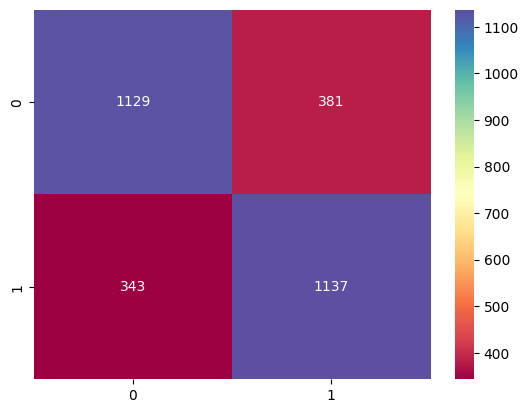

In [120]:
metricas = calc_metricas(reg_log, x_treino, y_treino, True)
print_metricas(metricas)

### 4.3 Árvore de decisão

In [121]:
arvore = DecisionTreeClassifier(random_state=404)
arvore.fit(x_treino, y_treino)
arvore.score(x_teste, y_teste)

0.7005347593582888

In [131]:
arvore.feature_importances_

array([0.35967813, 0.40742357, 0.04779683, 0.06284719, 0.08370188,
       0.03855241])

Acurácia: 0.8565
Precisão: 0.8563
Recall: 0.8534
F1-Score: 0.8548
Matriz de Confusão:


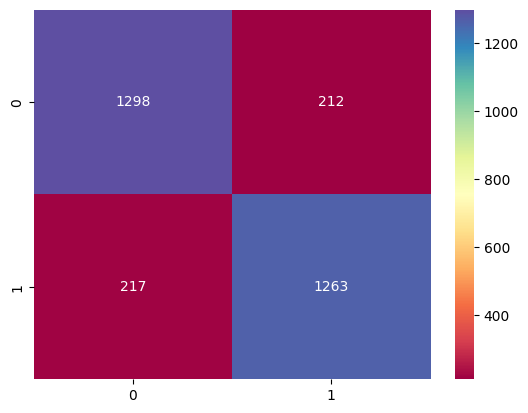

In [122]:
metricas = calc_metricas(arvore, x_treino, y_treino, False)
print_metricas(metricas)

### 4.4 KNN

In [123]:
knn = KNeighborsClassifier()
knn.fit(x_treino, y_treino)
knn.score(x_teste, y_teste)

0.7125668449197861

Acurácia: 0.8067
Precisão: 0.7847
Recall: 0.8399
F1-Score: 0.8114
Matriz de Confusão:


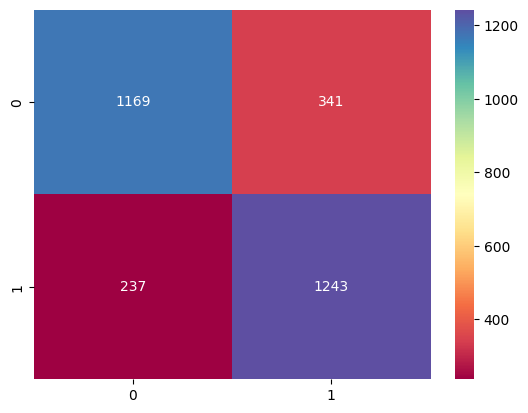

In [124]:
metricas = calc_metricas(knn, x_treino, y_treino, False)
print_metricas(metricas)

### 4.5 Floresta aleatória

In [125]:
rfc = RandomForestClassifier()
rfc.fit(x_treino, y_treino)
rfc.score(x_teste, y_teste)

0.6978609625668449

In [132]:
rfc.feature_importances_

array([0.17672172, 0.53255201, 0.09760464, 0.06968387, 0.07155705,
       0.05188071])

Acurácia: 0.8565
Precisão: 0.8315
Recall: 0.8905
F1-Score: 0.8600
Matriz de Confusão:


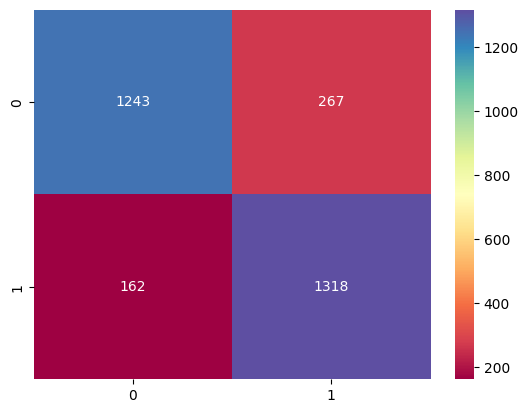

In [126]:
metricas = calc_metricas(rfc, x_treino, y_treino, False)
print_metricas(metricas)